# CNN Culinary Assistant Model Training
This notebook trains a Convolutional Neural Network (CNN) to recognize 22 different ingredients for the AI Kitchen Assistant.

**Project:** Bachelor's Degree Final Year Project (FYP) in Artificial Intelligence.


In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.16.1


In [22]:
# Check GPU
print("GPUs available:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())

GPUs available: []
Built with CUDA: False


## 1. Data Loading
Loading the images from the `dataset` folder using `image_dataset_from_directory`. We use an image size of 224x224, which is common for image classification models.

In [23]:
dataset_dir = 'dataset/train'
val_dir = 'dataset/valid'
test_dir = 'dataset/test'

batch_size = 32
img_height = 224
img_width = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  val_dir,
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Total classes:", len(class_names))

Found 8842 files belonging to 22 classes.
Found 1992 files belonging to 22 classes.
Classes: ['Bean', 'Beef', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Carrot', 'Cucumber', 'Lemongrass', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato', 'capsicum', 'cauliflower', 'chilli pepper', 'eggplant', 'garlic', 'ginger', 'onion']
Total classes: 22


## 2. Data Visualization
Let's visualize a few sample images from our training dataset along with their labels.

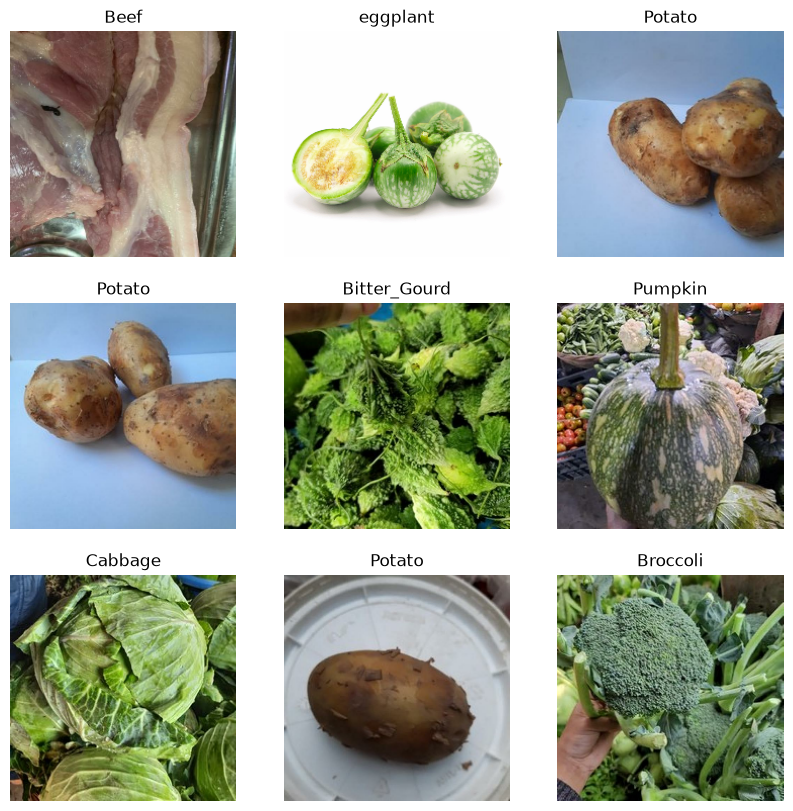

In [24]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.show()

## 3. Model Architecture
Here we define a standard Convolutional Neural Network (CNN) with Data Augmentation to prevent overfitting.

In [25]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

num_classes = len(class_names)

# 1. Load the pre-trained MobileNetV2 model (The "Transfer Learning" magic)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet'
)
# Freeze the base model so we don't destroy its pre-trained "brain"
base_model.trainable = False

# 2. Build our new powerful model on top of it
model = keras.Sequential([
  data_augmentation,
  layers.Rescaling(1./127.5, offset=-1), # MobileNetV2 requires pixels between -1 and 1
  base_model,
  layers.GlobalAveragePooling2D(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.2),
  layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

model.summary()

c:\Users\irfan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 22)             │         2,838 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,424,790 (9.25 MB)

 Trainable params: 166,806 (651.59 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Training the Model
We will train the model for 15 epochs. You can increase this for better accuracy!

In [26]:
epochs = 15
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 137s 474ms/step - accuracy: 0.9099 - loss: 0.3405 - val_accuracy: 0.5457 - val_loss: 4.8692
Epoch 2/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 128s 461ms/step - accuracy: 0.9793 - loss: 0.0745 - val_accuracy: 0.5457 - val_loss: 5.7473
Epoch 3/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 134s 483ms/step - accuracy: 0.9864 - loss: 0.0462 - val_accuracy: 0.5452 - val_loss: 6.4593
Epoch 4/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 133s 480ms/step - accuracy: 0.9904 - loss: 0.0329 - val_accuracy: 0.5452 - val_loss: 6.8793
Epoch 5/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 131s 473ms/step - accuracy: 0.9924 - loss: 0.0247 - val_accuracy: 0.5427 - val_loss: 7.3903
Epoch 6/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 128s 462ms/step - accuracy: 0.9902 - loss: 0.0307 - val_accuracy: 0.5447 - val_loss: 7.6807
Epoch 7/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 132s 478ms/step - accuracy: 0.9941 - loss: 0.0190 - val_accuracy: 0.5462 - val_loss: 8.4055
Epoch 8/15
277/277 ━━━━━━━━━━━━━━━━━━━━ 134s 484ms/step - accuracy: 0.9938 -

## 5. Training Visualization
Plotting the Accuracy and Loss graphs. These are perfect for your FYP report!

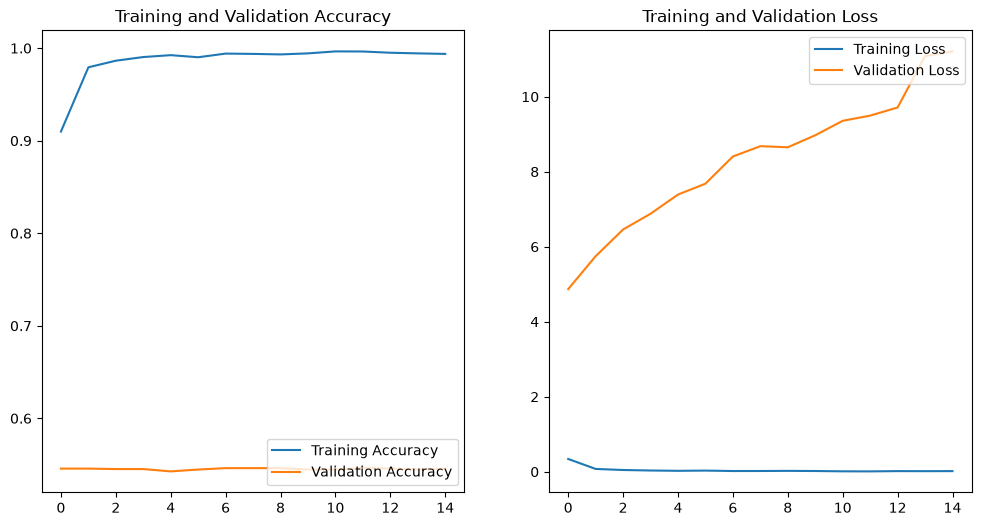

In [27]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 6. Export to TensorFlow Lite
Finally, we save the model to `.tflite` format so it can be deployed on the FastAPI backend!

In [28]:
# 1. Create a new model that skips the data_augmentation layer
export_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3))
])
for layer in model.layers[1:]:
    export_model.add(layer)

# 2. Use the new EXPORT function (Required for TensorFlow 2.16+)
export_model.export('my_saved_model')

# 3. Convert it
converter = tf.lite.TFLiteConverter.from_saved_model('my_saved_model')
tflite_model = converter.convert()

# 4. Save to TFLite
with open('culinary_assistant_model.tflite', 'wb') as f:
  f.write(tflite_model)
  
print("Model successfully exported to culinary_assistant_model.tflite!")

INFO:tensorflow:Assets written to: my_saved_model\assets


INFO:tensorflow:Assets written to: my_saved_model\assets


Saved artifact at 'my_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_498')
Output Type:
  TensorSpec(shape=(None, 22), dtype=tf.float32, name=None)
Captures:
  2259774380992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2259774379584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2259774382224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2259774379408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2259774380112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2259774379760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2259774382048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2259774382400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2259774380816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2259774376944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2259774379936: TensorSpec(shape

## 7. Model Evaluation — Precision, Recall, F1 Score & Confusion Matrix
Generate a full classification report and confusion matrix using the validation dataset.

In [33]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── Settings ──────────────────────────────────────────────────────────────
img_height = 224
img_width  = 224
batch_size = 32
val_dir    = 'dataset/valid'

# ── Reload validation dataset (labels_only=False to keep labels) ──────────
val_ds_eval = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False  # IMPORTANT: keep order consistent
)

class_names = val_ds_eval.class_names
print('Classes:', class_names)
print('Total classes:', len(class_names))

# ── Get true labels ───────────────────────────────────────────────────────
y_true = []
for _, labels in val_ds_eval:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# ── Get predictions from the trained model ────────────────────────────────
# Try to use the model variable from training (if still in memory)
# If not, reload from saved model
try:
    model  # check if model is still in memory
    print('Using model already in memory.')
except NameError:
    print('Model not in memory — loading from my_saved_model...')
    model = tf.keras.models.load_model('my_saved_model')

# Normalize validation images for prediction (MobileNetV2 needs [-1, 1])
val_ds_norm = val_ds_eval.map(lambda x, y: (tf.keras.applications.mobilenet_v2.preprocess_input(x), y))

y_pred_probs = model.predict(val_ds_eval, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f'\nTotal samples: {len(y_true)}')
print(f'Predictions shape: {y_pred.shape}')

Found 1992 files belonging to 22 classes.
Classes: ['Bean', 'Beef', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Lemongrass', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato', 'chilli pepper', 'eggplant', 'garlic', 'ginger', 'onion']
Total classes: 22
Using model already in memory.
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 368ms/step

Total samples: 1992
Predictions shape: (1992,)


### Classification Report (Precision, Recall, F1-Score per class)

In [34]:
# ── Full classification report ────────────────────────────────────────────
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)
print('Classification Report:')
print('=' * 70)
print(report)

# ── Also get weighted averages (for the paper table) ─────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall    = recall_score(y_true, y_pred, average='weighted')
f1        = f1_score(y_true, y_pred, average='weighted')

print('=' * 70)
print('SUMMARY (Weighted Average) — use these numbers in your paper:')
print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'  Precision : {precision:.4f} ({precision*100:.2f}%)')
print(f'  Recall    : {recall:.4f} ({recall*100:.2f}%)')
print(f'  F1 Score  : {f1:.4f} ({f1*100:.2f}%)')

Classification Report:
               precision    recall  f1-score   support

         Bean     0.9909    1.0000    0.9954       109
         Beef     1.0000    1.0000    1.0000       451
 Bitter_Gourd     1.0000    1.0000    1.0000       102
 Bottle_Gourd     1.0000    1.0000    1.0000        91
      Brinjal     1.0000    0.9877    0.9938        81
     Broccoli     1.0000    1.0000    1.0000        97
      Cabbage     0.9908    1.0000    0.9954       108
     Capsicum     0.0000    0.0000    0.0000        86
       Carrot     0.0000    0.0000    0.0000       102
  Cauliflower     0.0000    0.0000    0.0000        90
     Cucumber     0.0000    0.0000    0.0000        93
   Lemongrass     0.0000    0.0000    0.0000        51
       Papaya     0.0000    0.0000    0.0000       102
       Potato     0.0000    0.0000    0.0000        92
      Pumpkin     0.0000    0.0000    0.0000        90
       Radish     0.0000    0.0000    0.0000       101
       Tomato     0.0000    0.0000    0.0

### Confusion Matrix

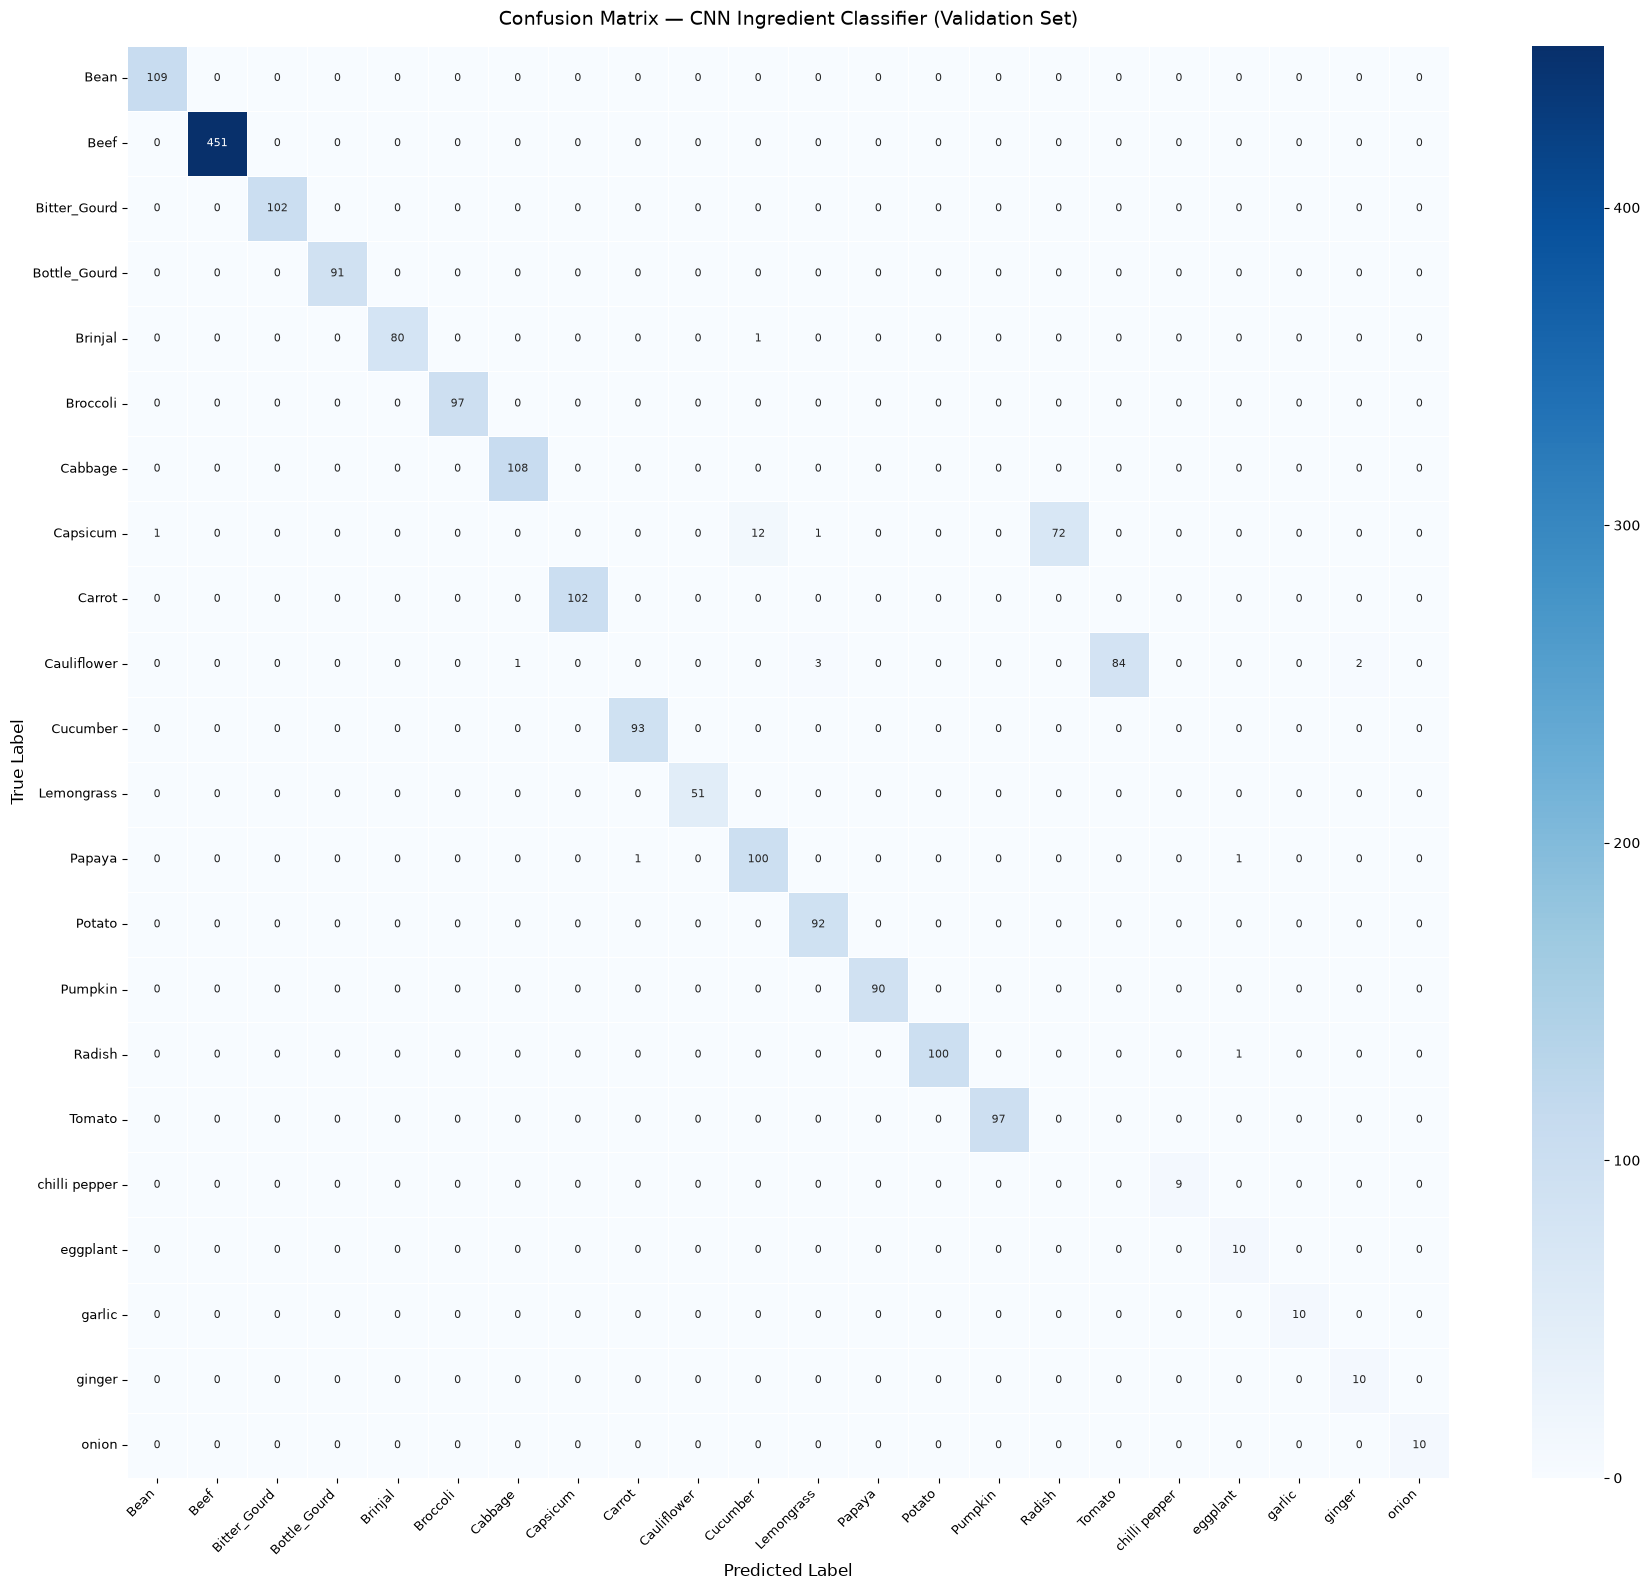

Confusion matrix saved as confusion_matrix.png


In [35]:
# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Confusion Matrix — CNN Ingredient Classifier (Validation Set)', fontsize=14, pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()
print('Confusion matrix saved as confusion_matrix.png')

### Per-Class Results Table (for Paper)

In [36]:
# ── Print a clean per-class table for copy into paper ─────────────────────
from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)

# Build a clean dataframe
rows = []
for cls in class_names:
    r = report_dict[cls]
    rows.append({
        'Class': cls,
        'Precision': f"{r['precision']:.4f}",
        'Recall':    f"{r['recall']:.4f}",
        'F1-Score':  f"{r['f1-score']:.4f}",
        'Support':   int(r['support'])
    })

# Add weighted average row
wa = report_dict['weighted avg']
rows.append({
    'Class': 'Weighted Avg',
    'Precision': f"{wa['precision']:.4f}",
    'Recall':    f"{wa['recall']:.4f}",
    'F1-Score':  f"{wa['f1-score']:.4f}",
    'Support':   int(wa['support'])
})

df = pd.DataFrame(rows)
print(df.to_string(index=False))
df.to_csv('classification_report.csv', index=False)
print('\nSaved as classification_report.csv')

        Class Precision Recall F1-Score  Support
         Bean    0.9909 1.0000   0.9954      109
         Beef    1.0000 1.0000   1.0000      451
 Bitter_Gourd    1.0000 1.0000   1.0000      102
 Bottle_Gourd    1.0000 1.0000   1.0000       91
      Brinjal    1.0000 0.9877   0.9938       81
     Broccoli    1.0000 1.0000   1.0000       97
      Cabbage    0.9908 1.0000   0.9954      108
     Capsicum    0.0000 0.0000   0.0000       86
       Carrot    0.0000 0.0000   0.0000      102
  Cauliflower    0.0000 0.0000   0.0000       90
     Cucumber    0.0000 0.0000   0.0000       93
   Lemongrass    0.0000 0.0000   0.0000       51
       Papaya    0.0000 0.0000   0.0000      102
       Potato    0.0000 0.0000   0.0000       92
      Pumpkin    0.0000 0.0000   0.0000       90
       Radish    0.0000 0.0000   0.0000      101
       Tomato    0.0000 0.0000   0.0000       97
chilli pepper    1.0000 1.0000   1.0000        9
     eggplant    0.8333 1.0000   0.9091       10
       garlic    1.0